In [15]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
#random forest import
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import mean_absolute_error, r2_score

#WHAT HOUSEHOLD FACTORSS ARE MORE LIKELY TO AFFECT ENERGY USAGE?
#Random forest searches for best feature among a subset of random features. Higher bias, lower variance

In [16]:
# Predicting: 
    # Regression: DOLLAREL, DOLLARNG, DOLLARFO, DOLLARLP, KWH
    # Categorical: SCALEB, SCALEG, SCALEE, PAYHELP, ENERGYASST, COLDMA, HOTMA
# Discarding: imputation variables, all other columns in the "ENERGY ASSISTANCE" and "End-use Model" sections
recs = pd.read_csv("recs2020_public_v7.csv")
recs = recs.dropna()            # drop rows with missing values

In [17]:
# Data Preprocessing ===========================================================================================================

In [18]:
# Removing imputation variables
z_cols = [col for col in recs.columns if col.startswith('Z')]
recs = recs.drop(columns=z_cols)
recs.head()

,DOEID,REGIONC,DIVISION,STATE_FIPS,state_postal,state_name,BA_climate,IECC_climate_code,UATYP10,HDD65,...,EVCHRGHOME,EVCHRGAPT,EVCHRGWKS,EVCHRGBUS,EVCHRGMUNI,EVCHRGDLR,EVCHRGHWY,EVCHRGOTH,EVHOMEAMT,EVCHRGTYPE
0,100001,WEST,Mountain South,35,NM,New Mexico,Mixed-Dry,4B,U,3844,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
1,100002,SOUTH,West South Central,5,AR,Arkansas,Mixed-Humid,4A,U,3766,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
2,100003,WEST,Mountain South,35,NM,New Mexico,Mixed-Dry,4B,U,3819,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
3,100004,SOUTH,South Atlantic,45,SC,South Carolina,Mixed-Humid,3A,U,2614,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
4,100005,NORTHEAST,Middle Atlantic,34,NJ,New Jersey,Mixed-Humid,4A,U,4219,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0


In [19]:
# Removing ENERGY ASSISTANCE columns
energy_asst_remove_cols = ["NOHEATBROKE", "NOHEATEL", "NOHEATNG", "NOHEATBULK", "NOHEATDAYS", "NOHEATHELP", "NOACBROKE", "NOACEL", "NOACDAYS", "NOACHELP", "ENERGYASST20", "ENERGYASST19", "ENERGYASST18", "ENERGYASST17", "ENERGYASST16", "ENERGYASSTOTH"]
recs = recs.drop(columns=energy_asst_remove_cols)
recs.head()

,DOEID,REGIONC,DIVISION,STATE_FIPS,state_postal,state_name,BA_climate,IECC_climate_code,UATYP10,HDD65,...,EVCHRGHOME,EVCHRGAPT,EVCHRGWKS,EVCHRGBUS,EVCHRGMUNI,EVCHRGDLR,EVCHRGHWY,EVCHRGOTH,EVHOMEAMT,EVCHRGTYPE
0,100001,WEST,Mountain South,35,NM,New Mexico,Mixed-Dry,4B,U,3844,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
1,100002,SOUTH,West South Central,5,AR,Arkansas,Mixed-Humid,4A,U,3766,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
2,100003,WEST,Mountain South,35,NM,New Mexico,Mixed-Dry,4B,U,3819,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
3,100004,SOUTH,South Atlantic,45,SC,South Carolina,Mixed-Humid,3A,U,2614,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
4,100005,NORTHEAST,Middle Atlantic,34,NJ,New Jersey,Mixed-Humid,4A,U,4219,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0


In [20]:
# Removing end-use model columns (except for DOLLAREL, DOLLARNG, DOLLARFO, DOLLARLP, KWH, which we are trying to predict)
end_model_remove_cols = ["BTUEL", "ELXBTU", "PERIODEL", "KWHSPH", "KWHCOL", "KWHWTH", "KWHRFG", "KWHRFG1", "KWHRFG2", "KWHFRZ", "KWHCOK", "KWHMICRO", "KWHCW", "KWHCDR", "KWHDWH", "KWHLGT", "KWHTVREL", "KWHTV1", "KWHTV2", "KWHTV3", "KWHAHUHEAT", "KWHAHUCOL", "KWHCFAN", "KWHDHUM", "KWHHUM", "KWHPLPMP", "KWHHTBPMP", "KWHHTBHEAT", "KWHEVCHRG", "KWHNEC", "KWHOTH", "BTUELSPH", "BTUELCOL", "BTUELWTH", "BTUELRFG", "BTUELRFG1", "BTUELRFG2", "BTUELFRZ", "BTUELCOK", "BTUELMICRO", "BTUELCW", "BTUELCDR", "BTUELDWH", "BTUELLGT", "BTUELTVREL", "BTUELTV1", "BTUELTV2", "BTUELTV3", "BTUELAHUHEAT", "BTUELAHUCOL", "BTUELCFAN", "BTUELDHUM", "BTUELHUM", "BTUELPLPMP", "BTUELHTBPMP", "BTUELHTBHEAT", "BTUELEVCHRG", "BTUELNEC", "BTUELOTH", "DOLELSPH", "DOLELCOL", "DOLELWTH", "DOLELRFG", "DOLELRFG1", "DOLELRFG2", "DOLELFRZ", "DOLELCOK", "DOLELMICRO", "DOLELCW", "DOLELCDR", "DOLELDWH", "DOLELLGT", "DOLELTVREL", "DOLELTV1", "DOLELTV2", "DOLELTV3", "DOLELAHUHEAT", "DOLELAHUCOL", "DOLELCFAN", "DOLELDHUM", "DOLELHUM", "DOLELPLPMP", "DOLELHTBPMP", "DOLELHTBHEAT", "DOLELEVCHRG", "DOLELNEC", "DOLELOTH", "CUFEETNG", "BTUNG", "NGXBTU", "PERIODNG", "BTUNGSPH", "BTUNGWTH", "BTUNGCOK", "BTUNGCDR", "BTUNGPLHEAT", "BTUNGHTBHEAT", "BTUNGNEC", "BTUNGOTH", "CUFEETNGSPH", "CUFEETNGWTH", "CUFEETNGCOK", "CUFEETNGCDR", "CUFEETNGPLHEAT", "CUFEETNGHTBHEAT", "CUFEETNGNEC", "CUFEETNGOTH", "DOLNGSPH", "DOLNGWTH", "DOLNGCOK", "DOLNGCDR", "DOLNGPLHEAT", "DOLNGHTBHEAT", "DOLNGNEC", "DOLNGOTH", "GALLONLP", "BTULP", "LPXBTU", "PERIODLP", "BTULPSPH", "BTULPWTH", "BTULPCOK", "BTULPCDR", "BTULPNEC", "BTULPOTH", "GALLONLPSPH", "GALLONLPWTH", "GALLONLPCOK", "GALLONLPCDR", "GALLONLPNEC", "GALLONLPOTH", "DOLLPSPH", "DOLLPWTH", "DOLLPCOK", "DOLLPCDR", "DOLLPNEC", "DOLLPOTH", "GALLONFO", "BTUFO", "FOXBTU", "PERIODFO", "BTUFOSPH", "BTUFOWTH", "BTUFONEC", "BTUFOOTH", "GALLONFOSPH", "GALLONFOWTH", "GALLONFONEC", "GALLONFOOTH", "DOLFOSPH", "DOLFOWTH", "DOLFONEC", "DOLFOOTH", "BTUWD", "TOTALBTUSPH", "TOTALDOLSPH", "TOTALBTUWTH", "TOTALDOLWTH", "TOTALBTUOTH", "TOTALDOLOTH", "TOTALBTU", "TOTALDOL"]
recs = recs.drop(columns=end_model_remove_cols)
recs.head()

,DOEID,REGIONC,DIVISION,STATE_FIPS,state_postal,state_name,BA_climate,IECC_climate_code,UATYP10,HDD65,...,EVCHRGHOME,EVCHRGAPT,EVCHRGWKS,EVCHRGBUS,EVCHRGMUNI,EVCHRGDLR,EVCHRGHWY,EVCHRGOTH,EVHOMEAMT,EVCHRGTYPE
0,100001,WEST,Mountain South,35,NM,New Mexico,Mixed-Dry,4B,U,3844,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
1,100002,SOUTH,West South Central,5,AR,Arkansas,Mixed-Humid,4A,U,3766,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
2,100003,WEST,Mountain South,35,NM,New Mexico,Mixed-Dry,4B,U,3819,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
3,100004,SOUTH,South Atlantic,45,SC,South Carolina,Mixed-Humid,3A,U,2614,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
4,100005,NORTHEAST,Middle Atlantic,34,NJ,New Jersey,Mixed-Humid,4A,U,4219,...,-2.0,-2,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0


In [21]:
# Defining features and targets
regression_targets = ["DOLLAREL", "DOLLARNG", "DOLLARFO", "DOLLARLP", "KWH"] #money/energy amounts spent
categorical_targets = ["SCALEB", "SCALEG", "SCALEE", "PAYHELP", "ENERGYASST", "COLDMA", "HOTMA"] #struggle factors

#separate targeted features from the rest of the features
X = recs.drop(columns=regression_targets + categorical_targets)

y_reg = recs[regression_targets]
y_cat = recs[categorical_targets]

In [22]:
# Encode the features (use Ordinal)
cat_feature_cols = X.select_dtypes(include='object').columns.tolist()
num_feature_cols = X.select_dtypes(include='number').columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_feature_cols] = enc.fit_transform(X[cat_feature_cols])

In [23]:
# Test Train Split - 80/20 train/test split
X_train, X_test, y_reg_train, y_reg_test, y_cat_train, y_cat_test = train_test_split(
    X, y_reg, y_cat, test_size=0.2, random_state=42
)

In [24]:
#*****REGRESSION with Random Forest Strategy*****
reg_models = {}
reg_scores = {}

for col in regression_targets:
    model = RandomForestRegressor(
        n_estimators=100,       # 100 trees
        max_depth=None,        # expand until pure
        min_samples_leaf=5,    # prevent overfitting by requiring at least 5 samples per leaf
        max_features='sqrt',   # splits consider sqrt(n) features
        n_jobs=-1,              
        random_state=42
    )
    model.fit(X_train, y_reg_train[col])
    preds = model.predict(X_test)

    reg_models[col] = model
    reg_scores[col] = {
        "MAE": mean_absolute_error(y_reg_test[col], preds),
        "R2":  r2_score(y_reg_test[col], preds)
    }

print("=== Regression (Random Forest) ===")
for col, scores in reg_scores.items():
    print(f"{col}: MAE={scores['MAE']:.2f}, R\u00b2={scores['R2']:.3f}")


#*****CLASSIFICATION with Random Forest*****
cat_models = {}
cat_scores = {}

for col in categorical_targets:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=5,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_cat_train[col])
    preds = model.predict(X_test)

    cat_models[col] = model
    cat_scores[col] = {
        "Accuracy": accuracy_score(y_cat_test[col], preds),
        "F1 (weighted)": f1_score(y_cat_test[col], preds, average='weighted')
    }

print("\n=== Classification (Random Forest) ===")
for col, scores in cat_scores.items():
    print(f"{col}: Accuracy={scores['Accuracy']:.3f}, F1={scores['F1 (weighted)']:.3f}")

=== Regression (Random Forest) ===
DOLLAREL: MAE=447.49, R²=0.433
DOLLARNG: MAE=125.00, R²=0.685
DOLLARFO: MAE=39.66, R²=0.788
DOLLARLP: MAE=47.08, R²=0.706
KWH: MAE=3135.91, R²=0.581

=== Classification (Random Forest) ===
SCALEB: Accuracy=0.824, F1=0.744
SCALEG: Accuracy=0.915, F1=0.875
SCALEE: Accuracy=0.911, F1=0.869
PAYHELP: Accuracy=0.911, F1=0.869
ENERGYASST: Accuracy=0.958, F1=0.937
COLDMA: Accuracy=0.994, F1=0.991
HOTMA: Accuracy=0.996, F1=0.993


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params for SCALEB: {'n_estimators': 50, 'min_samples_leaf': 5, 'max_depth': 20}
Tuned SCALEB - Accuracy: 0.824
Tuned SCALEB - F1:       0.745


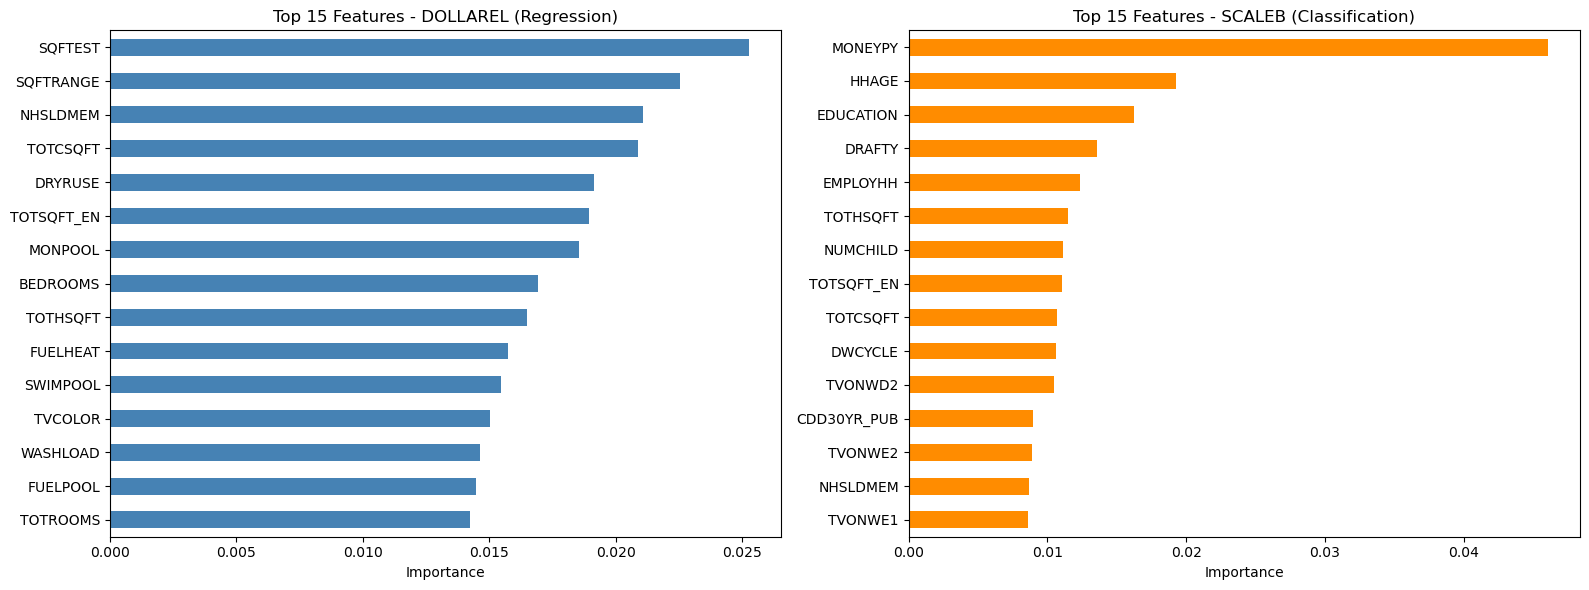

In [ ]:
from sklearn.model_selection import GridSearchCV

#from lecture, perform hyperparameter tuning using GridSearchCV
clf = RandomForestClassifier(random_state=156)

params = {
    'max_depth': np.arange(5, 30, 5),
    'n_estimators': np.arange(50, 210, 50)
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    return_train_score=True
)
grid_search.fit(X_train, y_cat_train["SCALEB"])

# Get best params
print("Best params for SCALEB:", grid_search.best_params_)

# Replace default SCALEB model with tuned one
cat_models["SCALEB"] = grid_search.best_estimator_

# Evaluate the tuned model
clf_best = grid_search.best_estimator_
y_test_pred = clf_best.predict(X_test)

print('Hyperparameter tuning of random forest yields test accuracy:', accuracy_score(y_cat_test["SCALEB"], y_test_pred))
print('F1 score is:', f1_score(y_cat_test["SCALEB"], y_test_pred, average='weighted'))

# --- FEATURE IMPORTANCE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features for DOLLAREL (Regression)
reg_importances = pd.Series(
    reg_models["DOLLAREL"].feature_importances_, index=X_train.columns
).nlargest(15)
reg_importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Top 15 Features - DOLLAREL (Regression)")
axes[0].set_xlabel("Importance")

# Top 15 features for SCALEB (now tuned)
cat_importances = pd.Series(
    cat_models["SCALEB"].feature_importances_, index=X_train.columns
).nlargest(15)
cat_importances.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("Top 15 Features - SCALEB (Tuned Classification)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# FINDINGS
## What household factors affect how households can struggle to pay bills?
- how big the house is
- hwo many members are in the hosuehold
- how much AC is used
- how much dryer is used
- fuel heat
- swimming pool? tvs?
DOLLAREL (Regression). predicts electricity cost in dollars
SCALEB (Classification).
- household income
employment
education
age of householder
home quality

 